In [12]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (14, 9),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

from TB.utils import make_secondary_axis_plot 

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondStructure import FixedRateBondStructure, FixedRateBondStructureFunctionMap
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue, FixedRateBondValueFunctionMap

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from TB.FixedRateBondsTB import FixedRateBondsTB
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

In [3]:
tb = TimeseriesBuilder(
    irswaps_tb=IRSwapsTB(mdp=IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")),
    fixedratebonds_tb=FixedRateBondsTB(mdp=FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")),
)

In [4]:
start = datetime.date(2025, 4, 10)
end = datetime.date(2025, 10, 9)

df = tb.get_timeseries(
    start=start,
    end=end,
    queries=[
        # FixedRateBondQuery(cusip="CT5/CT30", value=FixedRateBondValue.YTM), 
        FixedRateBondQuery(cusip="CT30", value=FixedRateBondValue.YTM), 
        IRSwapQuery(curve="USD-SOFR-1D", tenor="CT30", value=IRSwapValue.MMSS),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="CT30", value=IRSwapValue.SPREADOVER),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="2Y/10Y", value=IRSwapValue.RATE),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="oo2/oo10", value=IRSwapValue.RATE)
    ],
    # ignore_cache=True
)
df

PRICING FIXED-RATE BONDS.: 0it [00:00, ?it/s]
PRICING FIXED-RATE BONDS.: 0it [00:00, ?it/s]


FRB                    SWAPSPREADS  \
           CT30 OUTRIGHT YTM USD-SOFR-1D CT30 OUTRIGHT MMSS   
Date                                                          
2025-04-10          4.864062                     -95.467506   
2025-04-11          4.851790                     -88.397856   
2025-04-14          4.802974                     -88.861006   
2025-04-15          4.786824                     -88.813971   
2025-04-16          4.744708                     -89.814853   
...                      ...                            ...   
2025-10-03          4.712400                     -78.791225   
2025-10-06          4.761472                     -79.013618   
2025-10-07          4.726000                     -77.077693   
2025-10-08          4.724000                     -76.468676   
2025-10-09          4.729000                     -76.954291   

                                                 
           USD-SOFR-1D CT30 OUTRIGHT SPREADOVER  
Date                                             
2025-04-10                           -94.109751  
2025-04-11                           -87.046683  
2025-04-14                           -87.416253  
2025-04-15                           -87.322792  
2025-04-16                           -88.261849  
...                                         ...  
2025-10-03                           -78.795619  
2025-10-06                           -79.024882  
2025-10-07                           -77.095483  
2025-10-08                           -76.492058  
2025-10-09                           -77.045720  

[126 rows x 3 columns]

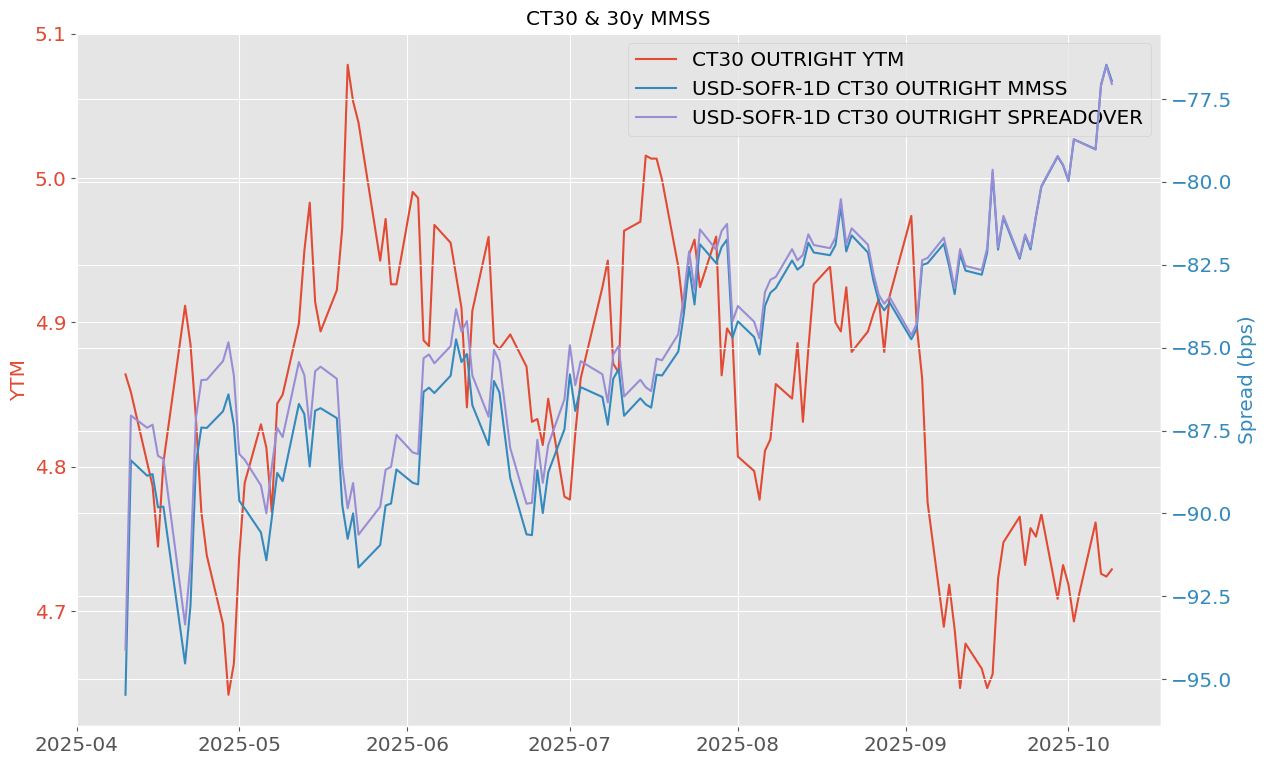

In [13]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left="YTM",
    ylabel_right="Spread (bps)",
    title="CT30 & 30y MMSS"
)

plot(df["FRB"]["CT30 OUTRIGHT YTM"], which="left")
plot(df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT MMSS"], which="right")
plot(df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT SPREADOVER"], which="right")

legend()
plt.show()




# plt.plot(df.index, df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT SPREADOVER"])

In [7]:
FixedRateBondQuery(cusip="ct2/ct5/ct10", value=FixedRateBondValue.YTM).col_name()

'ct2/ct5/ct10 FLY YTM'

In [13]:
(3.655120 - 4.127839) * 100

-47.27189999999997

In [13]:
IRSwapQuery(curve="USD-SOFR-1D", tenor="CT2/CT5/CT10", structure_kwargs={"risk_weights": [-0.67, 1, -0.31]}).col_name()

'USD-SOFR-1D CT2/CT5/CT10 -0.67/1/-0.31 FLY RATE'

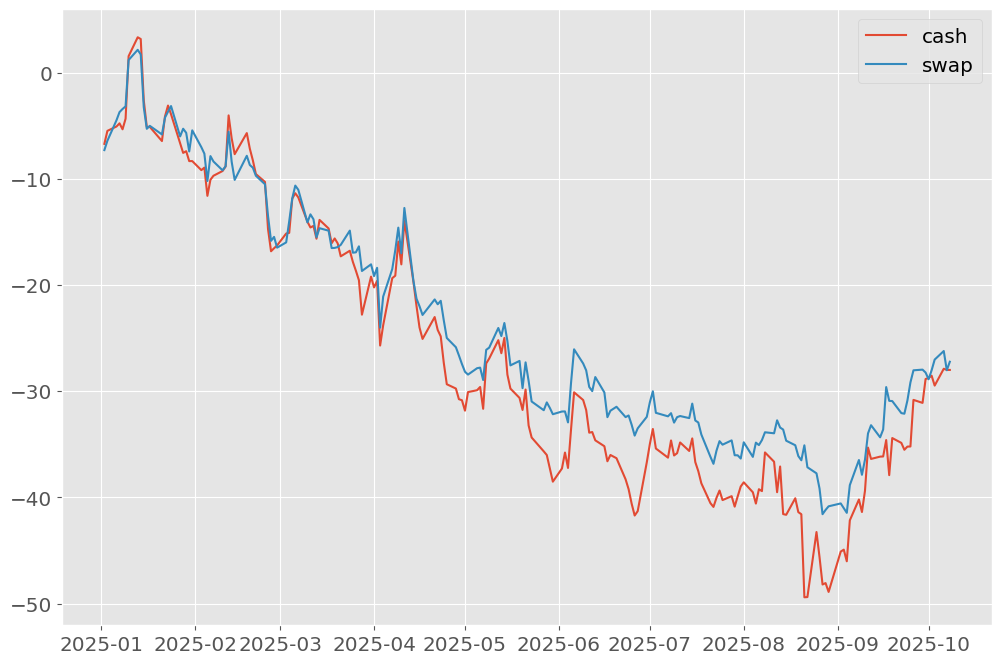

In [9]:
plt.Figure()
plt.plot(df.index, df["FixedRateBond"]["ct2/ct5/ct10 FLY YTM"], label="cash")
plt.plot(df.index, df["IRS"]["USD-SOFR-1D 2Y/5Y/10Y FLY RATE"], label="swap")
plt.legend()
plt.show()